# Storage ($G'$) and Loss ($G''$) Moduli

We can calculate the storage and loss moduli on the smooth $G(t)$ using (https://pubs.acs.org/doi/10.1021/acs.macromol.3c01893?ref=pdf)


$$G^\prime(\omega) = \omega \int_0^\infty G(t)\sin(\omega t) dt$$

$$G^{\prime\prime}(\omega) = \omega \int_0^\infty G(t)\cos(\omega t) dt$$


This evidently does not work. Due to the large values of $\omega t$, there is a significant amount of numeric instability. 

Let's instead use the implementation here (https://arxiv.org/pdf/2203.03752, appendix A).

$$\int_0^\infty G(t) \exp(-i\omega t)dt \approx $$
$$\sum_{k=1}^N \exp(-i\omega t_{k-1}) \left\{G_k \left( \frac{\exp(-i\omega\Delta t_k)-1}{\omega^2\Delta t_k} - \frac{\exp(-i\omega \Delta t_k)}{i\omega} \right) - G_{k-1}\left(\frac{\exp(-i\omega\Delta t_k)-1}{\omega^2\Delta t_k} - \frac{1}{i\omega}\right)\right\}.$$

In [31]:
import numpy as np

def fourier_integral_moduli(t, G, omega):
    """
    Compute F(omega) = \int_0^\infty G(t) e^{-i omega t} dt
    using the discrete approximation
      sum_{k=1..N} exp(-i omega t_{k-1}) * { ... }  (as provided)
    Inputs:
      t     : 1D array of times, length M >= 2, increasing (t0..t_{M-1})
      G     : 1D array of G(t) values at those times (len == M)
      omega : scalar or 1D array of frequencies (rad/time)
    Returns:
      F    : complex array with shape (len(omega),) (or scalar if scalar omega)
      Gp   : real array G'(omega) = -omega * Im[F]
      Gpp  : real array G''(omega) =  omega * Re[F]
    Notes:
      - The formula assumes G is piecewise-defined on intervals [t_{k-1}, t_k].
      - For omega == 0 we fall back to trapezoidal integration.
    """
    t = np.asarray(t, dtype=float)
    G = np.asarray(G, dtype=float)
    if t.ndim != 1 or G.ndim != 1 or len(t) != len(G):
        raise ValueError("t and G must be 1D arrays of same length")

    omega_arr = np.atleast_1d(np.array(omega, dtype=float)) # make into a 1D array
    scalar_input = np.isscalar(omega)

    # segments: k = 1..N where N = M-1
    t_prev = t[:-1]         # t_{k-1}, shape (N,)
    dt = np.diff(t)         # Δt_k, shape (N,)
    G_prev = G[:-1]         # G_{k-1}
    G_k = G[1:]             # G_k

    if np.any(dt <= 0):
        raise ValueError("t must be strictly increasing")

    # prepare arrays for broadcasting
    W = omega_arr[:, None]          # shape (n_omega, 1)
    Tprev = t_prev[None, :]         # shape (1, N)
    DT = dt[None, :]                # shape (1, N)
    G_prev_mat = G_prev[None, :]    # shape (1, N)
    G_k_mat = G_k[None, :]          # shape (1, N)

    # handle omega == 0 separately
    # integral evaluates to simple trapezoidal integral of G(t)
    zero_mask = np.isclose(omega_arr, 0.0)
    F = np.zeros(omega_arr.shape, dtype=np.complex128)

    # 1) For zero-frequency entries use trapezoidal integral:
    if np.any(zero_mask):
        # simple trapezoid on original t/G
        F_zero = np.trapz(G, t)  # real
        F[zero_mask] = F_zero

    # 2) For non-zero omega, compute according to your discrete formula
    if np.any(~zero_mask):
        w_nz = omega_arr[~zero_mask]
        W_nz = w_nz[:, None]                 # (n_nz, 1)
        # compute exponentials
        exp_iw_dt = np.exp(-1j * W_nz * DT)  # shape (n_nz, N)
        exp_iw_tprev = np.exp(-1j * W_nz * Tprev)  # shape (n_nz, N)

        # avoid division by tiny omega^2 * dt or i*omega issues:
        # compute denominators
        w2 = (W_nz**2)            # shape (n_nz, 1)
        iw = 1j * W_nz            # shape (n_nz, 1)

        # compute the common piece (exp(-i w dt) - 1) / (w^2 dt)
        numer = (exp_iw_dt - 1.0)                     # (n_nz, N)
        denom = w2 * DT                               # (n_nz, N)
        # safe division - where denom is tiny, use Taylor expansion:
        small_mask = np.abs(denom) < 1e-16
        common = np.empty_like(numer, dtype=np.complex128)
        # safe division where denom not tiny
        ok = ~small_mask
        common[ok] = numer[ok] / denom[ok]
        # Taylor expansion for small x = w*dt: (e^{-i x}-1)/(w^2 dt)
        # numerator ~ -i x + (-x^2/2) + i(x^3/6) ...
        # (e^{-i x}-1)/(w^2 dt) ≈ (-i x - x^2/2 + ...)/(w^2 dt)
        # but x = w*dt so denominator w^2 dt = x^2/w => series simplifies;
        # The leading-order term: (-i w dt)/(w^2 dt) = -i / w
        # Next term: (- (w dt)^2/2)/(w^2 dt) = -dt/2
        # We'll use expansion up to O(dt)
        if np.any(small_mask):
            x = (W_nz * DT)[small_mask]  # small
            # compute approx: -i / w + (-DT/2) + O(w*dt)
            # note shapes align because small_mask selects elements
            approx = (-1j / W_nz[small_mask.any(axis=1)][:, None])  # shape hack - simpler compute elementwise below
            # Instead of trying to be too clever with shapes, compute elementwise fallback:
            it = np.nditer(small_mask, flags=['multi_index'])
            while not it.finished:
                i, j = it.multi_index  # i - omega index, j - segment index
                if small_mask[i, j]:
                    wval = W_nz[i, 0]
                    dtval = DT[0, j]
                    xval = wval * dtval
                    # series to O(dt)
                    common[i, j] = (-1j / wval) - 0.5 * dtval
                it.iternext()

        # compute the other denominators with iw
        # A = (exp(-i w dt) / (i w))
        # B = (1 / (i w))
        A = exp_iw_dt / (1j * W_nz)      # (n_nz, N)
        B = 1.0 / (1j * W_nz)            # (n_nz, 1) broadcasts

        # construct the bracketed expression for each segment:
        # term_k = G_k * ( common - exp(-i w dt) / (i w) )
        # minus G_{k-1} * ( common - 1/(i w) )
        term1 = G_k_mat * (common - A)
        term2 = G_prev_mat * (common - B)

        # full segment contributions (with exp(-i w t_{k-1}) factor)
        seg = exp_iw_tprev * (term1 - term2)   # shape (n_nz, N)

        # sum segments
        F_nz = np.sum(seg, axis=1)             # shape (n_nz,)
        # store back
        F[~zero_mask] = F_nz

    # final outputs: G' = -omega * Im(F), G'' = omega * Re(F)
    # ensure correct shape matching omega_arr
    Gp = -omega_arr * F.imag
    Gpp = omega_arr * F.real

    # return shapes consistent with input omega
    if scalar_input:
        return F[0], float(Gp[0]), float(Gpp[0])
    else:
        return F, Gp, Gpp


<>:4: SyntaxWarning: invalid escape sequence '\i'
<>:4: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_1633476/3290729079.py:4: SyntaxWarning: invalid escape sequence '\i'
  """


# Testing simple exponential G(t) (Maxwell Model relaxation)

To verify the method above works, we will apply it to a Maxwell model (simple spring + dashpot model) and see if we get the expected storage and loss moduli.

The dynamic modulus of a simple Maxwell model is an exponential, with the form

$$G(t) = k e^{-\frac k \eta t}$$

and examining it in comparison to the expected form (https://pubs.rsc.org/en/content/articlehtml/2020/sm/d0sm00354a, Fig. 2)

False
Maxwell model G(t) min, max: 4.5399929762484854e-05 0.9048374180359595
Smallest and largest dt: 0.004761575278966493 0.45451543338165834


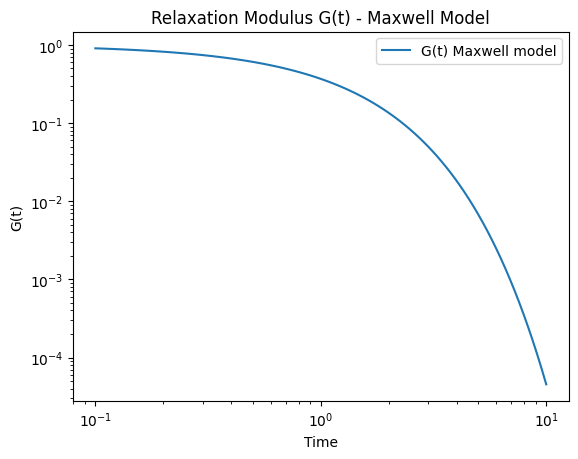

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Test of moduli function using a Maxwell model G(t) = k * exp(- (k/eta) * t)

k = 1
eta = 1.0
t = np.logspace(-1, 1, 100)
G_t = k * np.exp(- (k / eta) * t)

print(np.any(~np.isfinite(G_t))) # should be False
print("Maxwell model G(t) min, max:", G_t.min(), G_t.max())
print("Smallest and largest dt:", np.min(np.diff(t)), np.max(np.diff(t)))

# plt.loglog(t, G_t , label='G(t) Maxwell model')
plt.loglog(t, G_t , label='G(t) Maxwell model')
plt.xlabel('Time')
plt.ylabel('G(t)')
plt.title('Relaxation Modulus G(t) - Maxwell Model')
plt.legend()
plt.show()



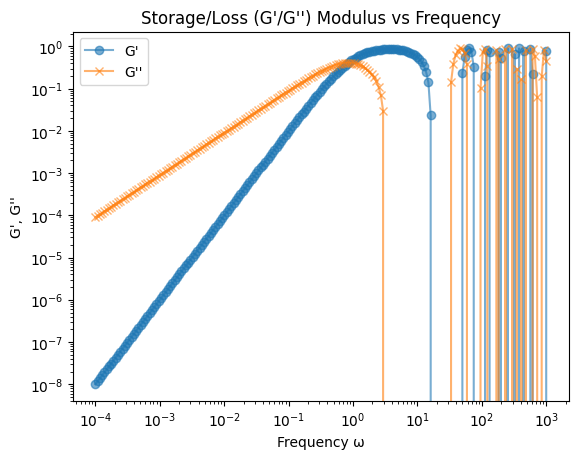

In [33]:
# t_start = 0
# t_end = 
# n data points
n = 200
omega = np.logspace(-4, 3, n)
F, Gp, Gpp = fourier_integral_moduli(t, G_t, omega)
plt.loglog(omega, Gp, marker='o', alpha=0.6, label="G'")
plt.loglog(omega, Gpp, marker='x', alpha=0.6, label="G''")
plt.xlabel('Frequency ω')
plt.ylabel("G', G''")
plt.title("Storage/Loss (G'/G'') Modulus vs Frequency")
plt.legend()
plt.show()


Due to the log spacing of the multiple-tau output, I'm going to test a trapezoid integral. The calculation above is very unstable when $\Delta t$ gets large.

In [34]:
def fourier_moduli_uneven_vec(t, G, omega):
    t = np.asarray(t)
    G = np.asarray(G)
    omega = np.atleast_1d(omega)
    
    exp_matrix = np.exp(-1j * np.outer(omega, t))  # shape (len(omega), len(t))
    F = np.trapz(G * exp_matrix, t, axis=1)
    
    Gp = -omega * F.imag
    Gpp = omega * F.real
    return F, Gp, Gpp

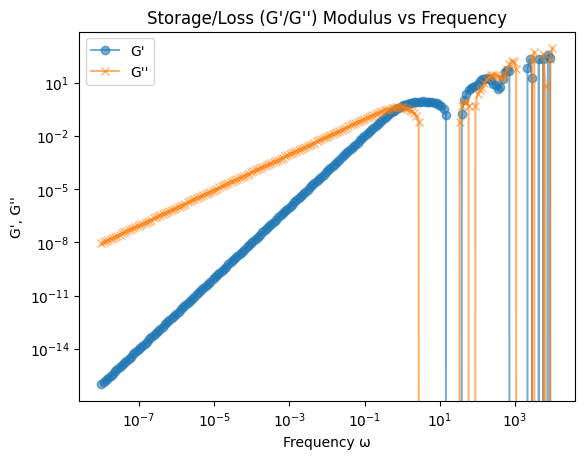

In [35]:

# n data points
n = 200
omega = np.logspace(-8, 4, n)
F, Gp, Gpp = fourier_moduli_uneven_vec(t, G_t, omega)
plt.loglog(omega, Gp, marker='o', alpha=0.6, label="G'")
plt.loglog(omega, Gpp, marker='x', alpha=0.6, label="G''")
plt.xlabel('Frequency ω')
plt.ylabel("G', G''")
plt.title("Storage/Loss (G'/G'') Modulus vs Frequency")
plt.legend()
plt.show()


## Spacing list

In [36]:
spacing_list = [0, 15, 10, 5, 4, 3, 2]

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_Gt_vs_time():
    G_list = []
    time_list = []
    for i in spacing_list:
        for seed in [1000]:
            try:
                file = f"data/press_50_spacing{i}_seed{seed}.dat"
                data = pd.read_csv(file, delimiter=' ', skiprows=3, index_col=False, names=['time', 'px_y', 'px_z', 'py_z', 'pxy', 'pxz', 'pyz'])
                print(f"Processing file for spacing {i} with seed {seed}...")
                if i == 0:
                    bonding_density = 0
                else:
                    bonding_density = round((1 / i), 3)

                data = data[data['time'] >= t_start]
                data = data[data['time'] <= t_end]

                G_t = (data['pxy'] + data['pxz'] + data['pyz']) / 5.0 + \
                        (data['px_y'] + data['px_z'] + data['py_z']) / 30.0

                # replace negative with NaN
                G_t = np.where(G_t < 0, np.nan, G_t)

                G_list.append(G_t)
                time_list.append(data['time'])

                # G_t *= 40**3 / (1.0 * 1.0)  # V / (kB * T)

                plt.loglog(data['time'], G_t, alpha=0.5, label=f'bonding_density={bonding_density}')
                # save file as space separated values
                output_file = f"data/processed_Gt_spacing{i}_seed{seed}.dat"
                processed_data = pd.DataFrame({'time': data['time'], 'G_t': G_t})
                processed_data.to_csv(output_file, sep=' ', index=False)
                print(f"Processed data saved to {output_file}")
            except FileNotFoundError:
                print(f"File for spacing {i} seed {seed} not found. Skipping.")

Processing file for spacing 0 with seed 1000...
Processed data saved to data/processed_Gt_spacing0_seed1000.dat
Processing file for spacing 15 with seed 1000...
Processed data saved to data/processed_Gt_spacing15_seed1000.dat
Processing file for spacing 10 with seed 1000...
Processed data saved to data/processed_Gt_spacing10_seed1000.dat
Processing file for spacing 5 with seed 1000...
Processed data saved to data/processed_Gt_spacing5_seed1000.dat
Processing file for spacing 4 with seed 1000...
Processed data saved to data/processed_Gt_spacing4_seed1000.dat
Processing file for spacing 3 with seed 1000...
Processed data saved to data/processed_Gt_spacing3_seed1000.dat
Processing file for spacing 2 with seed 1000...
Processed data saved to data/processed_Gt_spacing2_seed1000.dat


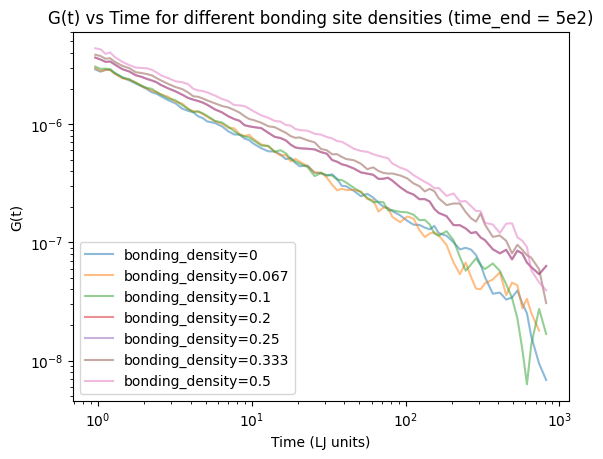

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



# t_start = -np.inf
# t_end = np.inf
t_start = 9e-1
t_end = 9e2

plot_Gt_vs_time()

plt.legend()
# plt.xlim([t_start, t_end])
# plt.ylim([1e-7, 1e-3])
plt.xlabel('Time (LJ units)')
plt.ylabel('G(t)')
plt.title('G(t) vs Time for different bonding site densities (time_end = 5e2)')
plt.show()

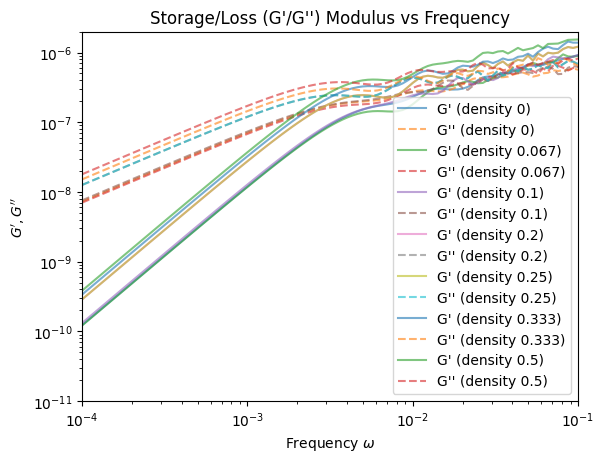

In [338]:
# apply fourier integral to each G(t) in G_list
storage_moduli = []
loss_moduli = []
n = 100
omega = np.logspace(-4, -1, n)


for i in spacing_list:
    for seed in [1000]:
        try:
            file = f"processed_Gt_spacing{i}_seed{seed}.dat"
            data = pd.read_csv(file, delimiter=' ', skiprows=3, index_col=False, names=['time', 'G_t'])
            if i == 0:
                bonding_density = 0
            else:
                bonding_density = round((1 / i), 3)
            G_t = data['G_t'].values
            time = data['time'].values
            # print(len(time), len(G_t))
            # find NaN values and remove them
            mask = ~np.isnan(G_t)
            time = time[mask]
            G_t = G_t[mask]

            # zero pad G_t and time to next power of 2
            # N = len(G_t)
            # N_pad = 2**int(np.ceil(np.log2(N)))
            # G_t = np.pad(G_t, (0, N_pad - N), 'constant', constant_values=(0, 0))
            # time = np.pad(time, (0, N_pad - N), 'constant', constant_values=(0, time[-1] + (time[1]-time[0]) * np.arange(1, N_pad - N + 1)))  
            
        except FileNotFoundError:
            print(f"File for spacing {i} seed {seed} not found. Skipping.")
            continue

        F, Gp, Gpp = fourier_integral_moduli(time, G_t, omega)
        # print(len(omega), len(Gp), len(Gpp))
        # print(Gp)
        # storage_moduli.append(Gp)
        # loss_moduli.append(Gpp)
        plt.loglog(omega, Gp, linestyle='-', alpha=0.6, label=f"G' (density {bonding_density})")
        plt.loglog(omega, Gpp, linestyle='--', alpha=0.6, label=f"G'' (density {bonding_density})")
        plt.xlabel(r'Frequency $\omega$')
        plt.ylabel("$G', G''$")
        plt.xlim([1e-4, 1e-1])
        plt.ylim([1e-11, 2e-6])
        plt.title("Storage/Loss (G'/G'') Modulus vs Frequency")
        plt.legend()

plt.show()

In [339]:
def plot_storage_moduli():


    for i in spacing_list:
        for seed in [1000]:
            try:
                file = f"processed_Gt_spacing{i}_seed{seed}.dat"
                data = pd.read_csv(file, delimiter=' ', skiprows=3, index_col=False, names=['time', 'G_t'])
                if i == 0:
                    bonding_density = 0
                else:
                    bonding_density = round((1 / i), 3)
                G_t = data['G_t'].values
                time = data['time'].values
                # print(len(time), len(G_t))
                # find NaN values and remove them
                mask = ~np.isnan(G_t)
                time = time[mask]
                G_t = G_t[mask]

                # zero pad G_t and time to next power of 2
                # N = len(G_t)
                # N_pad = 2**int(np.ceil(np.log2(N)))
                # G_t = np.pad(G_t, (0, N_pad - N), 'constant', constant_values=(0, 0))
                # time = np.pad(time, (0, N_pad - N), 'constant', constant_values=(0, time[-1] + (time[1]-time[0]) * np.arange(1, N_pad - N + 1)))  
                
            except FileNotFoundError:
                print(f"File for spacing {i} seed {seed} not found. Skipping.")
                continue

            F, Gp, Gpp = fourier_integral_moduli(time, G_t, omega)
            # print(len(omega), len(Gp), len(Gpp))
            # print(Gp)
            # storage_moduli.append(Gp)
            # loss_moduli.append(Gpp)
            plt.loglog(omega, Gp, linestyle='-', alpha=0.6, label=f"G' (density {bonding_density})")
            plt.xlabel(r'Frequency $\omega$')
            plt.ylabel("$G', G''$")
            plt.xlim([1e-4, 1e-1])
            plt.ylim([1e-11, 2e-6])
            plt.title("Storage/Loss (G'/G'') Modulus vs Frequency")


    omega_ref = 3e-2
    idx = np.argmin(np.abs(omega - omega_ref))
    G_ref = Gp[idx]

    plt.loglog(omega[omega < 8e-3], G_ref * (omega[omega < 8e-3] / omega_ref)**2,
            linestyle=':', linewidth=2, label=r'$\omega^2$')

    omega_ref = 1e-3
    idx = np.argmin(np.abs(omega - omega_ref))
    G_ref = Gp[idx]

    plt.loglog(omega[omega > 8e-3], G_ref * (omega[omega > 8e-3] / omega_ref)**0.5,
            linestyle='-.', linewidth=2, label=r'$\omega^{1/2}$')
    plt.legend()
    
def plot_loss_moduli():

    for i in spacing_list:
        for seed in [1000]:
            try:
                file = f"processed_Gt_spacing{i}_seed{seed}.dat"
                data = pd.read_csv(file, delimiter=' ', skiprows=3, index_col=False, names=['time', 'G_t'])
                if i == 0:
                    bonding_density = 0
                else:
                    bonding_density = round((1 / i), 3)
                G_t = data['G_t'].values
                time = data['time'].values
                # print(len(time), len(G_t))
                # find NaN values and remove them
                mask = ~np.isnan(G_t)
                time = time[mask]
                G_t = G_t[mask]

                # zero pad G_t and time to next power of 2
                # N = len(G_t)
                # N_pad = 2**int(np.ceil(np.log2(N)))
                # G_t = np.pad(G_t, (0, N_pad - N), 'constant', constant_values=(0, 0))
                # time = np.pad(time, (0, N_pad - N), 'constant', constant_values=(0, time[-1] + (time[1]-time[0]) * np.arange(1, N_pad - N + 1)))  
                
            except FileNotFoundError:
                print(f"File for spacing {i} seed {seed} not found. Skipping.")
                continue

            F, Gp, Gpp = fourier_integral_moduli(time, G_t, omega)
            # print(len(omega), len(Gp), len(Gpp))
            # print(Gp)
            # storage_moduli.append(Gp)
            # loss_moduli.append(Gpp)
            plt.loglog(omega, Gpp, linestyle='--', alpha=0.6, label=f"G'' (density {bonding_density})")
            plt.xlabel(r'Frequency $\omega$')
            plt.ylabel("$G', G''$")
            plt.xlim([1e-4, 1e-1])
            plt.ylim([1e-11, 2e-6])
            plt.title("Storage/Loss (G'/G'') Modulus vs Frequency")
            plt.legend()

    omega_ref = 5e-5
    idx = np.argmin(np.abs(omega - omega_ref))
    G_ref = Gp[idx]

    plt.loglog(omega, omega * G_ref / omega_ref,
            linestyle=':', linewidth=2, label=r'$\omega$')


    plt.legend()


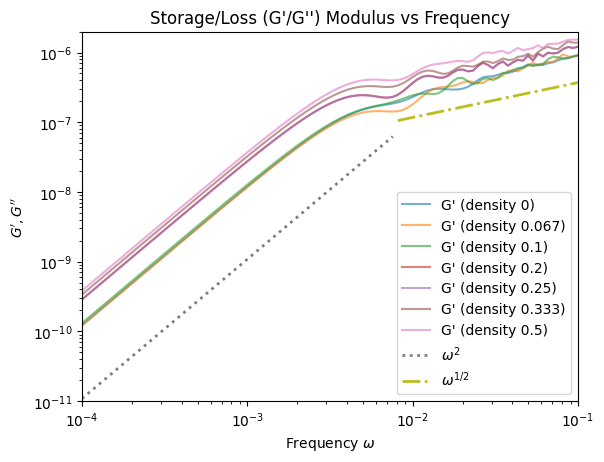

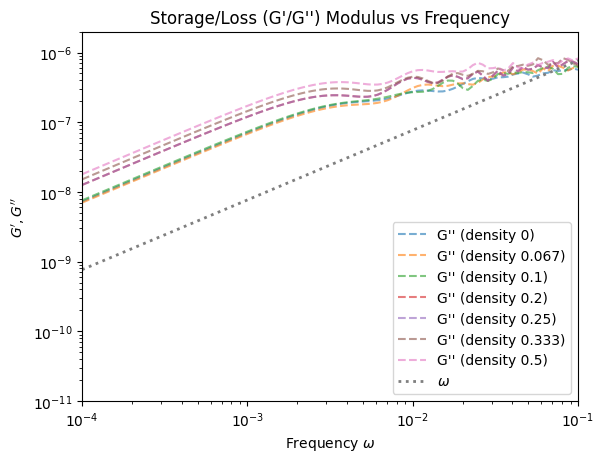

In [340]:
# apply fourier integral to each G(t) in G_list
storage_moduli = []
loss_moduli = []
n = 100
omega = np.logspace(-4, -1, n)

plot_storage_moduli()

plt.show()


# apply fourier integral to each G(t) in G_list
storage_moduli = []
loss_moduli = []
n = 100
omega = np.logspace(-4, -1, n)

plot_loss_moduli()

plt.show()


## different bonding strengths

Processing file for bonding strength 50 spacing 4 with seed 1000...
Processed data saved to processed_Gt_bonding50_spacing4_seed1000.dat
Processing file for bonding strength 55 spacing 4 with seed 1000...
Processed data saved to processed_Gt_bonding55_spacing4_seed1000.dat
Processing file for bonding strength 60 spacing 4 with seed 1000...
Processed data saved to processed_Gt_bonding60_spacing4_seed1000.dat
Processing file for bonding strength 65 spacing 4 with seed 1000...
Processed data saved to processed_Gt_bonding65_spacing4_seed1000.dat
Processing file for bonding strength 75 spacing 4 with seed 1000...
Processed data saved to processed_Gt_bonding75_spacing4_seed1000.dat


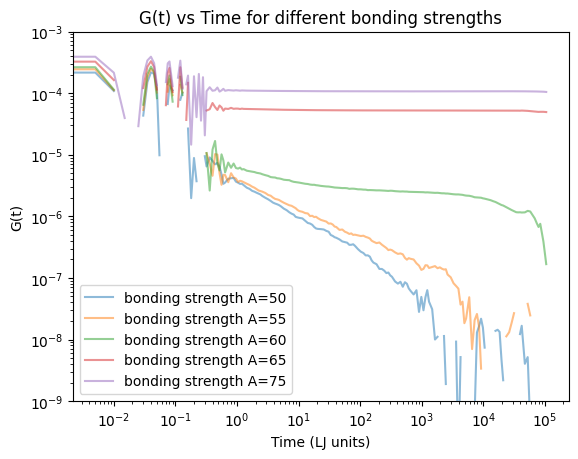

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

G_list = []
time_list = []

t_start = -np.inf
t_end = np.inf
# t_start = 9e-1
# t_end = 2e2


for i in [50, 55, 60, 65, 75]:
    for seed in [1000]:
        try:
            file = f"logs/press_{i}_spacing4_seed{seed}.dat"
            data = pd.read_csv(file, delimiter=' ', skiprows=3, index_col=False, names=['time', 'px_y', 'px_z', 'py_z', 'pxy', 'pxz', 'pyz'])
            print(f"Processing file for bonding strength {i} spacing 4 with seed {seed}...")
            if i == 0:
                bonding_density = 0
            else:
                bonding_density = round((1 / i), 3)

            data = data[data['time'] >= t_start]
            data = data[data['time'] <= t_end]

            G_t = (data['pxy'] + data['pxz'] + data['pyz']) / 5.0 + \
                    (data['px_y'] + data['px_z'] + data['py_z']) / 30.0

            # replace negative with NaN
            G_t = np.where(G_t < 0, np.nan, G_t)

            G_list.append(G_t)
            time_list.append(data['time'])

            # G_t *= 40**3 / (1.0 * 1.0)  # V / (kB * T)

            plt.loglog(data['time'], G_t, alpha=0.5, label=f'bonding strength A={i}')
            # save file as space separated values
            output_file = f"processed_Gt_bonding{i}_spacing4_seed{seed}.dat"
            processed_data = pd.DataFrame({'time': data['time'], 'G_t': G_t})
            processed_data.to_csv(output_file, sep=' ', index=False)
            print(f"Processed data saved to {output_file}")
        except FileNotFoundError:
            print(f"File for bonding {i} spacing 4 seed {seed} not found. Skipping.")

plt.legend()
# plt.xlim([t_start, t_end])
plt.ylim([1e-9, 1e-3])
plt.xlabel('Time (LJ units)')
plt.ylabel('G(t)')
plt.title('G(t) vs Time for different bonding strengths')
plt.show()


# plt.xlabel('Time (LJ units)')
# plt.ylabel('C(t)')
# plt.title('Averaged C(t) vs Time for different bonding site densities')
# plt.show()

In [ ]:
# apply fourier integral to each G(t) in G_list
storage_moduli = []
loss_moduli = []
n = 100
omega = np.logspace(-4, -1, n)


for i in [50, 75, 100]:
    for seed in [1000]:
        try:
            file = f"data/processed_Gt_spacing{i}_seed{seed}.dat"
            data = pd.read_csv(file, delimiter=' ', skiprows=3, index_col=False, names=['time', 'G_t'])
            if i == 0:
                bonding_density = 0
            else:
                bonding_density = round((1 / i), 3)
            G_t = data['G_t'].values
            time = data['time'].values
            # print(len(time), len(G_t))
            # find NaN values and remove them
            mask = ~np.isnan(G_t)
            time = time[mask]
            G_t = G_t[mask]

            # zero pad G_t and time to next power of 2
            # N = len(G_t)
            # N_pad = 2**int(np.ceil(np.log2(N)))
            # G_t = np.pad(G_t, (0, N_pad - N), 'constant', constant_values=(0, 0))
            # time = np.pad(time, (0, N_pad - N), 'constant', constant_values=(0, time[-1] + (time[1]-time[0]) * np.arange(1, N_pad - N + 1)))  
            
        except FileNotFoundError:
            print(f"File for spacing {i} seed {seed} not found. Skipping.")
            continue

        F, Gp, Gpp = fourier_integral_moduli(time, G_t, omega)
        # print(len(omega), len(Gp), len(Gpp))
        # print(Gp)
        # storage_moduli.append(Gp)
        # loss_moduli.append(Gpp)
        plt.loglog(omega, Gp, marker='o', alpha=0.6, label=f"G' (density {bonding_density})")
        plt.loglog(omega, Gpp, marker='x', alpha=0.6, label=f"G'' (density {bonding_density})")
        plt.xlabel(r'Frequency $\omega$')
        plt.ylabel("$G', G''$")
        plt.title("Storage/Loss (G'/G'') Modulus vs Frequency")
        plt.legend()

        plt.show()

In [179]:
# apply fourier integral to each G(t) in G_list

n = 100
omega = np.logspace(-4, -1, n)
for G_t, time in zip(G_list, time_list):
    Gp = []
    Gpp = []
    for w in omega:
        Gp.append(storage_modulus(w, G_t, time, integration_points=5000))
        Gpp.append(loss_modulus(w, G_t, time, integration_points=5000))
    plt.loglog(omega, Gp, marker='o', alpha=0.6, label="G'")
    plt.loglog(omega, Gpp, marker='x', alpha=0.6, label="G''")
    plt.xlabel('Frequency ω')
    plt.ylabel("G', G''")
    plt.title("Storage/Loss (G'/G'') Modulus vs Frequency")
    plt.legend()

plt.show()

KeyError: 0

Processing file for spacing 15 with seed 1000...
Processed data saved to processed_Gt_spacing15_seed1000.dat
Processing file for spacing 10 with seed 1000...
Processed data saved to processed_Gt_spacing10_seed1000.dat
Processing file for spacing 5 with seed 1000...
Processed data saved to processed_Gt_spacing5_seed1000.dat
Processing file for spacing 2 with seed 1000...
Processed data saved to processed_Gt_spacing2_seed1000.dat
Processing file for spacing 0 with seed 1000...
Processed data saved to processed_Gt_spacing0_seed1000.dat


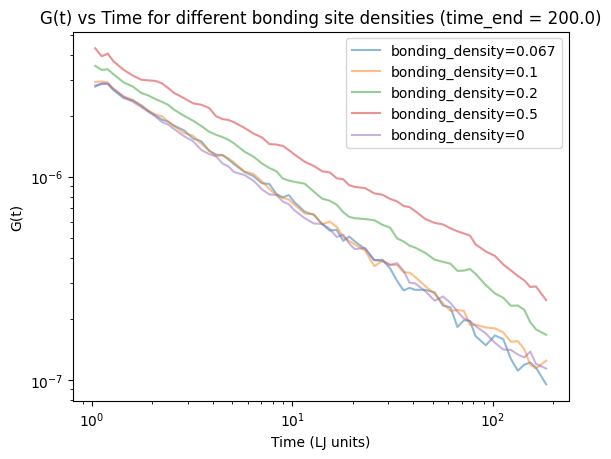

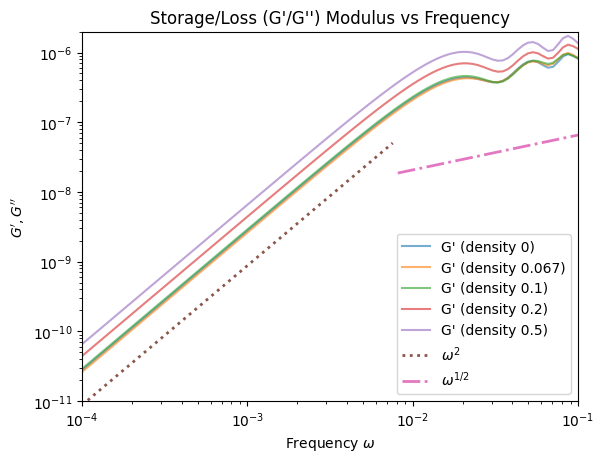

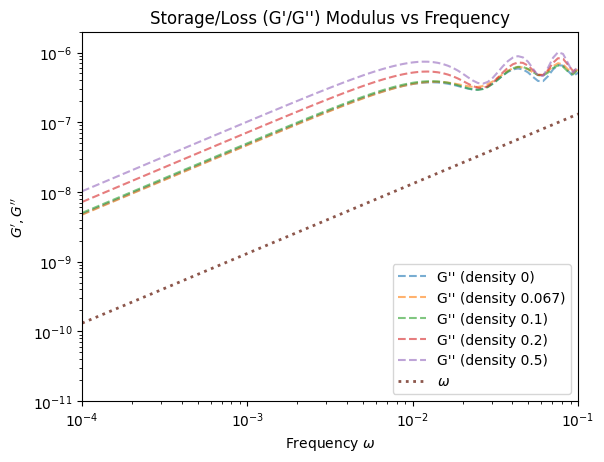

Processing file for spacing 15 with seed 1000...
Processed data saved to processed_Gt_spacing15_seed1000.dat
Processing file for spacing 10 with seed 1000...
Processed data saved to processed_Gt_spacing10_seed1000.dat
Processing file for spacing 5 with seed 1000...
Processed data saved to processed_Gt_spacing5_seed1000.dat
Processing file for spacing 2 with seed 1000...
Processed data saved to processed_Gt_spacing2_seed1000.dat
Processing file for spacing 0 with seed 1000...
Processed data saved to processed_Gt_spacing0_seed1000.dat


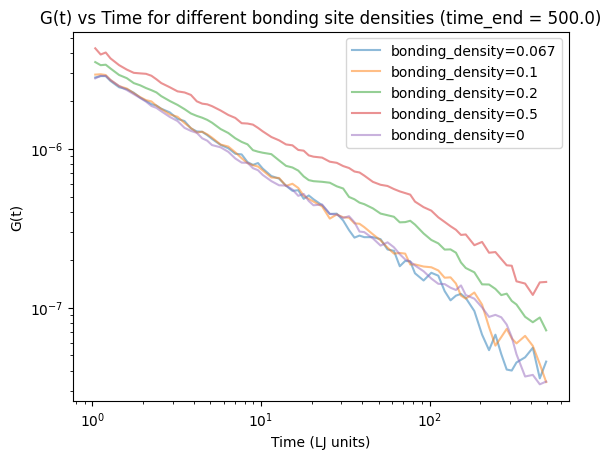

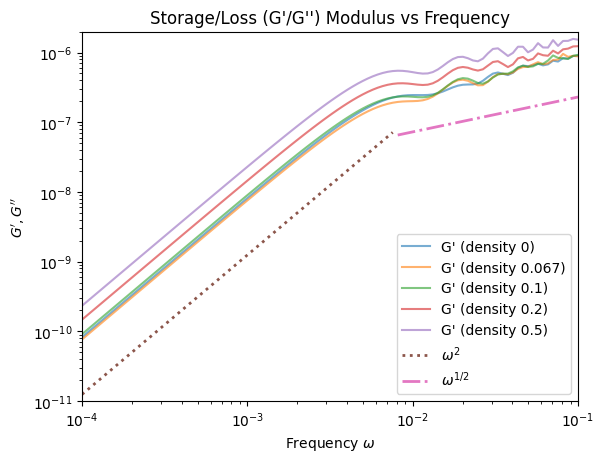

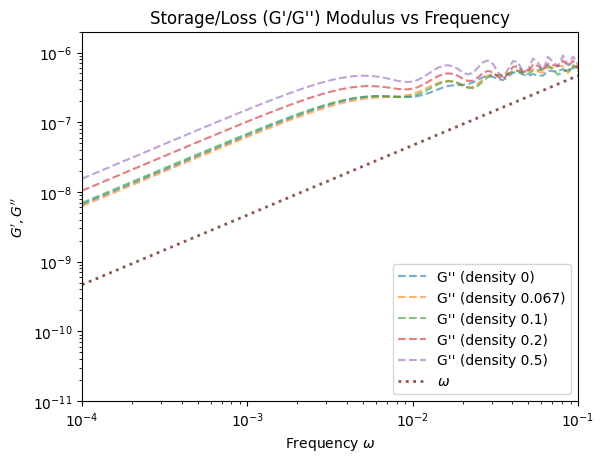

Processing file for spacing 15 with seed 1000...
Processed data saved to processed_Gt_spacing15_seed1000.dat
Processing file for spacing 10 with seed 1000...
Processed data saved to processed_Gt_spacing10_seed1000.dat
Processing file for spacing 5 with seed 1000...
Processed data saved to processed_Gt_spacing5_seed1000.dat
Processing file for spacing 2 with seed 1000...
Processed data saved to processed_Gt_spacing2_seed1000.dat
Processing file for spacing 0 with seed 1000...
Processed data saved to processed_Gt_spacing0_seed1000.dat


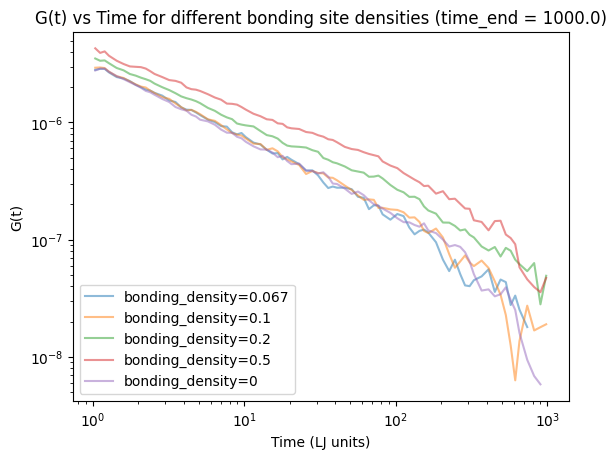

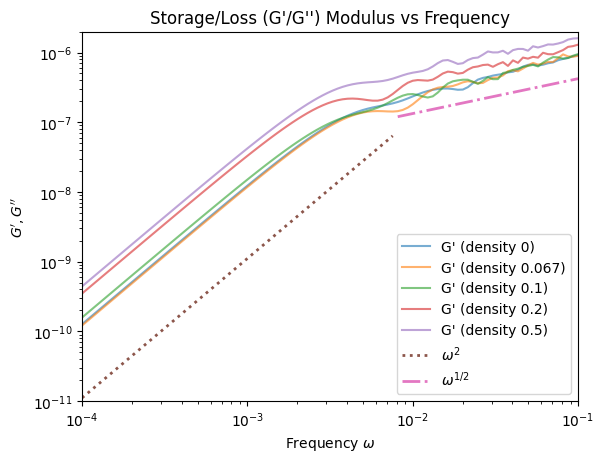

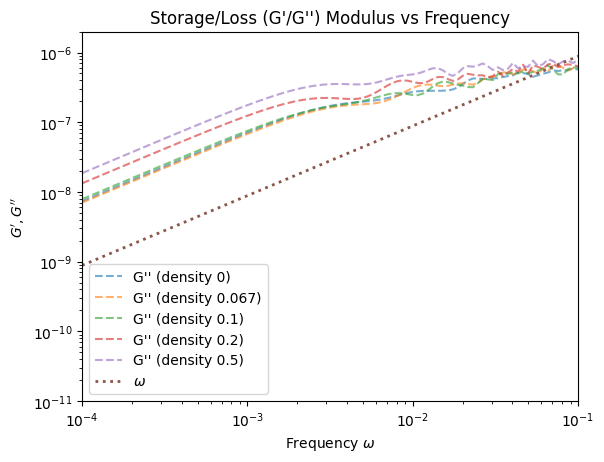

Processing file for spacing 15 with seed 1000...
Processed data saved to processed_Gt_spacing15_seed1000.dat
Processing file for spacing 10 with seed 1000...
Processed data saved to processed_Gt_spacing10_seed1000.dat
Processing file for spacing 5 with seed 1000...
Processed data saved to processed_Gt_spacing5_seed1000.dat
Processing file for spacing 2 with seed 1000...
Processed data saved to processed_Gt_spacing2_seed1000.dat
Processing file for spacing 0 with seed 1000...
Processed data saved to processed_Gt_spacing0_seed1000.dat


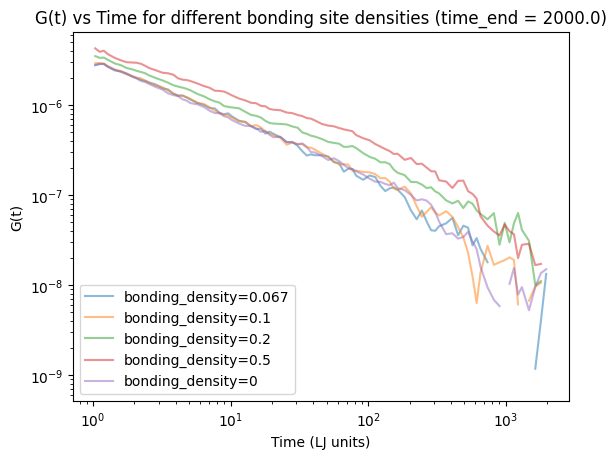

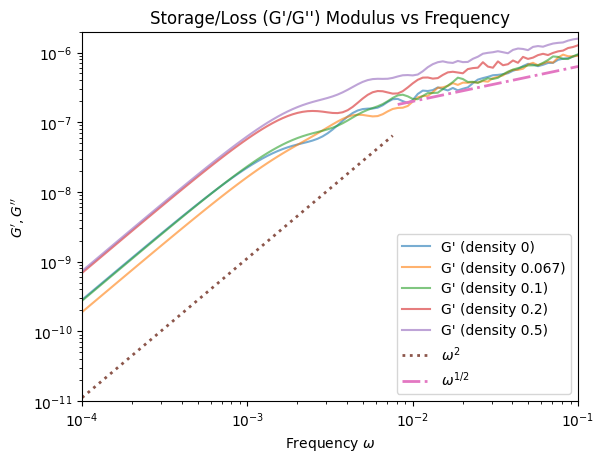

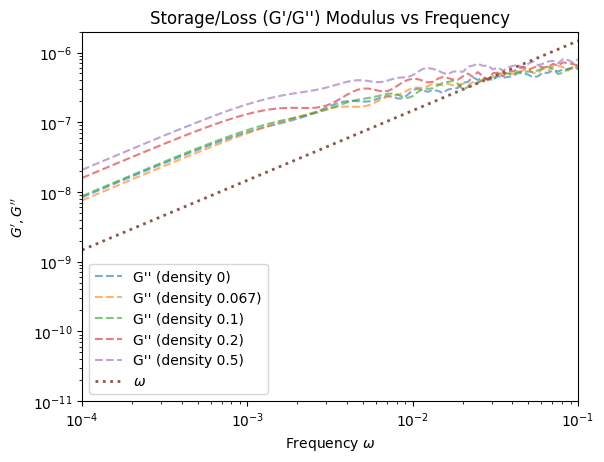

Processing file for spacing 15 with seed 1000...
Processed data saved to processed_Gt_spacing15_seed1000.dat
Processing file for spacing 10 with seed 1000...
Processed data saved to processed_Gt_spacing10_seed1000.dat
Processing file for spacing 5 with seed 1000...
Processed data saved to processed_Gt_spacing5_seed1000.dat
Processing file for spacing 2 with seed 1000...
Processed data saved to processed_Gt_spacing2_seed1000.dat
Processing file for spacing 0 with seed 1000...
Processed data saved to processed_Gt_spacing0_seed1000.dat


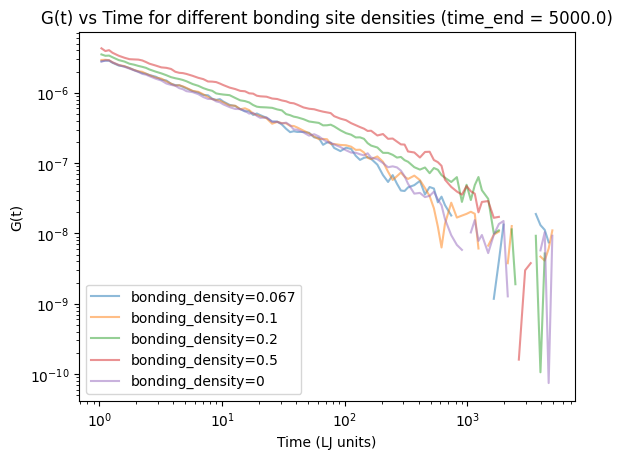

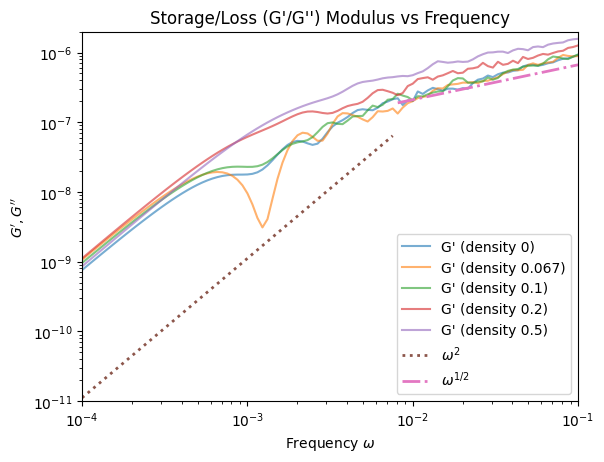

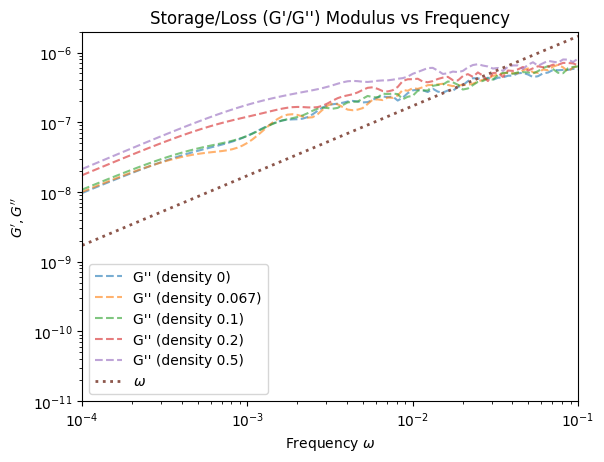

Processing file for spacing 15 with seed 1000...
Processed data saved to processed_Gt_spacing15_seed1000.dat
Processing file for spacing 10 with seed 1000...
Processed data saved to processed_Gt_spacing10_seed1000.dat
Processing file for spacing 5 with seed 1000...
Processed data saved to processed_Gt_spacing5_seed1000.dat
Processing file for spacing 2 with seed 1000...
Processed data saved to processed_Gt_spacing2_seed1000.dat
Processing file for spacing 0 with seed 1000...
Processed data saved to processed_Gt_spacing0_seed1000.dat


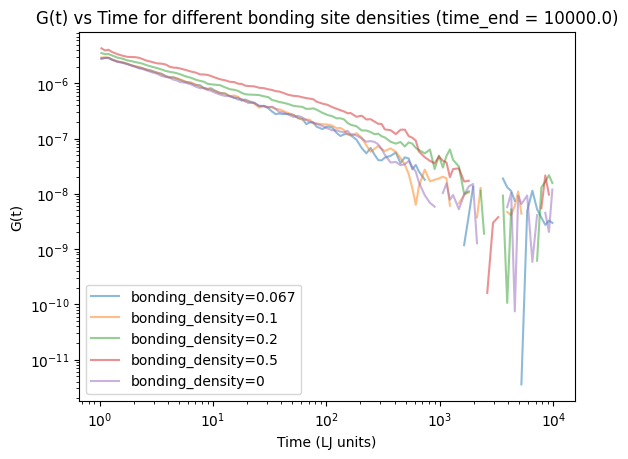

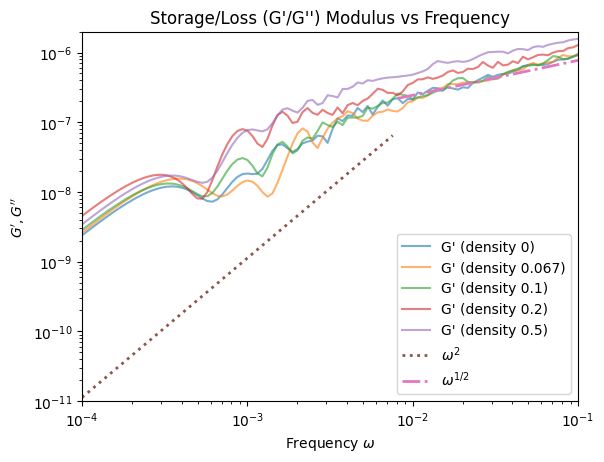

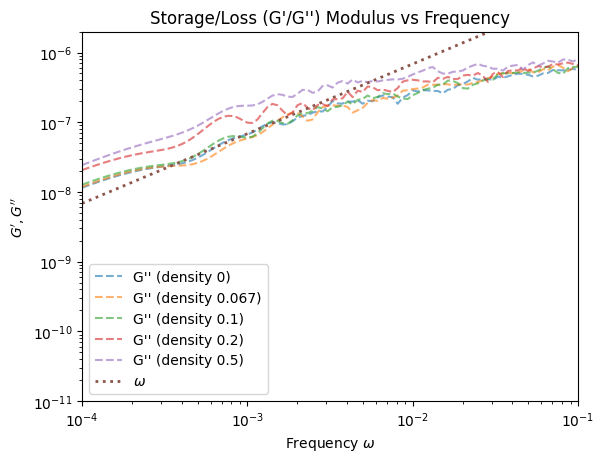

In [302]:
# Testing different t_end

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


t_end_candidates = [2e2, 5e2, 1e3, 2e3, 5e3, 1e4]
for t_end in t_end_candidates:
    # t_start = -np.inf
    # t_end = np.inf
    t_start = 9e-1
    # t_end = 2e3

    plot_Gt_vs_time()

    plt.legend()
    # plt.xlim([t_start, t_end])
    # plt.ylim([1e-7, 1e-3])
    plt.xlabel('Time (LJ units)')
    plt.ylabel('G(t)')
    plt.title(f'G(t) vs Time for different bonding site densities (time_end = {t_end})')
    plt.show()

    # apply fourier integral to each G(t) in G_list
    storage_moduli = []
    loss_moduli = []
    n = 100
    omega = np.logspace(-4, -1, n)

    plot_storage_moduli()

    plt.show()


    # apply fourier integral to each G(t) in G_list
    storage_moduli = []
    loss_moduli = []
    n = 100
    omega = np.logspace(-4, -1, n)

    plot_loss_moduli()

    plt.show()



# plt.xlabel('Time (LJ units)')
# plt.ylabel('C(t)')
# plt.title('Averaged C(t) vs Time for different bonding site densities')
# plt.show()

Processing file for spacing 2 with seed 1000...
Processing file for spacing 0 with seed 1000...
Processing file for spacing 15 with seed 200...
Processing file for spacing 10 with seed 200...
Processing file for spacing 5 with seed 200...
Processing file for spacing 4 with seed 200...
Processing file for spacing 3 with seed 200...


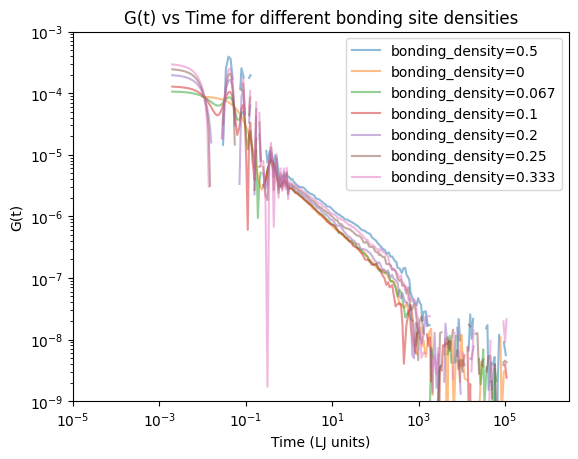

In [163]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

G_list = []
time_list = []

t_start = 1e-5
t_end = 3e6


for i in [2, 0]:
    for seed in [1000]:
        try:
            file = f"logs/press_50_spacing{i}_seed{seed}.dat"
            data = pd.read_csv(file, delimiter=' ', skiprows=3, index_col=False, names=['time', 'px_y', 'px_z', 'py_z', 'pxy', 'pxz', 'pyz'])
            print(f"Processing file for spacing {i} with seed {seed}...")
            if i == 0:
                bonding_density = 0
            else:
                bonding_density = round((1 / i), 3)

            data = data[data['time'] >= t_start]
            data = data[data['time'] <= t_end]

            G_t = (data['pxy'] + data['pxz'] + data['pyz']) / 5.0 + \
                    (data['px_y'] + data['px_z'] + data['py_z']) / 30.0

            # replace negative with NaN
            G_t = np.where(G_t < 0, np.nan, G_t)

            G_list.append(G_t)
            time_list.append(data['time'])

            # G_t *= 40**3 / (1.0 * 1.0)  # V / (kB * T)

            plt.loglog(data['time'][start:], G_t[start:], alpha=0.5, label=f'bonding_density={bonding_density}')
        except FileNotFoundError:
            print(f"File for spacing {i} seed {seed} not found. Skipping.")

for i in [15, 10, 5, 4, 3]:
    for seed in [200]:
        try:
            file = f"logs/press_50_spacing{i}_seed{seed}.dat"
            data = pd.read_csv(file, delimiter=' ', skiprows=3, index_col=False, names=['time', 'px_y', 'px_z', 'py_z', 'pxy', 'pxz', 'pyz'])
            print(f"Processing file for spacing {i} with seed {seed}...")
            if i == 0:
                bonding_density = 0
            else:
                bonding_density = round((1 / i), 3) 
            
            data = data[data['time'] >= t_start]
            data = data[data['time'] <= t_end]

            G_t = (data['pxy'] + data['pxz'] + data['pyz']) / 5.0 + \
                    (data['px_y'] + data['px_z'] + data['py_z']) / 30.0

            # replace negative with NaN
            G_t = np.where(G_t < 0, np.nan, G_t)

            G_list.append(G_t)
            time_list.append(data['time'])
            
            # G_t *= 48.075**3 / (1.0 * 1.0)  # V / (kB * T)
            
            plt.loglog(data['time'][start:], G_t[start:], alpha=0.5, label=f'bonding_density={bonding_density}')
        except FileNotFoundError:
            print(f"File for spacing {i} seed {seed} not found. Skipping.")

plt.legend()
plt.xlim([t_start, t_end])
plt.ylim([1e-9, 1e-3])
plt.xlabel('Time (LJ units)')
plt.ylabel('G(t)')
plt.title('G(t) vs Time for different bonding site densities')
plt.show()


# plt.xlabel('Time (LJ units)')
# plt.ylabel('C(t)')
# plt.title('Averaged C(t) vs Time for different bonding site densities')
# plt.show()